# Phase 2 Analysis — Superstore Dataset

## Section 1: Discount Policy and Profit Erosion

**Objective:** Move from description to business interpretation. The core question is not *what* the discount levels are, but *whether they are justified* — and whether the profit losses observed are the result of discount policy or structural cost problems.

**Analytical frame:**
$$\text{Observed Margin} = \text{Base Margin}_{(d=0\%)} + \text{Discount-Driven Erosion}$$

Separating these two components determines whether a recommendation targets pricing, costs, or commercial policy.

**Questions addressed in this notebook:**
- **1.1** What is the optimal discount policy per sub-category to maximize profit?
- **1.2** Do discounts above 20% generate enough volume to compensate for margin loss?
- **1.3** What would happen to global profit if all discounts above 20% were eliminated?

---
## Setup

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
db_path = Path('../data/superstore.db')
conn = sqlite3.connect(db_path)
df = pd.read_sql_query('SELECT * FROM orders', conn)
conn.close()

print(f'Records loaded: {len(df):,}')
print(f'Columns: {list(df.columns)}')

Records loaded: 9,993
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## 1.1 — Optimal Discount Policy by Sub-Category

### Approach

Two-step analysis:

1. **Heatmap (visual support):** Profit margin across discount buckets for every sub-category. Shows where and how fast margins deteriorate as discounts increase — the visual basis for every recommendation.
2. **Breakeven calculation:** For each sub-category, identify the last discount bucket where margin remains positive. That upper bound becomes the recommended maximum discount.

> **Methodological note on elasticity:** This dataset contains historical transaction records, not a controlled pricing experiment. We cannot measure true price-demand elasticity. Volume patterns by discount bucket are treated as descriptive evidence, not causal claims.

In [3]:
BUCKET_ORDER = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']

def assign_bucket(d):
    if d == 0:       return '0%'
    elif d <= 0.10:  return '1-10%'
    elif d <= 0.20:  return '11-20%'
    elif d <= 0.30:  return '21-30%'
    elif d <= 0.50:  return '31-50%'
    else:            return '>50%'

df['discount_bucket'] = df['Discount'].apply(assign_bucket)

# Weighted margin per sub-category / bucket: sum(Profit) / sum(Sales)
# Using sum/sum avoids distortion from small-value transactions.
bucket_stats = (
    df.groupby(['Sub-Category', 'discount_bucket'])
    .agg(profit=('Profit', 'sum'), sales=('Sales', 'sum'), n=('Profit', 'count'))
    .assign(margin=lambda x: x['profit'] / x['sales'])
    .reset_index()
)

pivot = (
    bucket_stats
    .pivot(index='Sub-Category', columns='discount_bucket', values='margin')
    .reindex(columns=BUCKET_ORDER)
)

# Sort by base margin (0% discount) descending — puts strongest sub-cats at top
pivot = pivot.sort_values('0%', ascending=False)

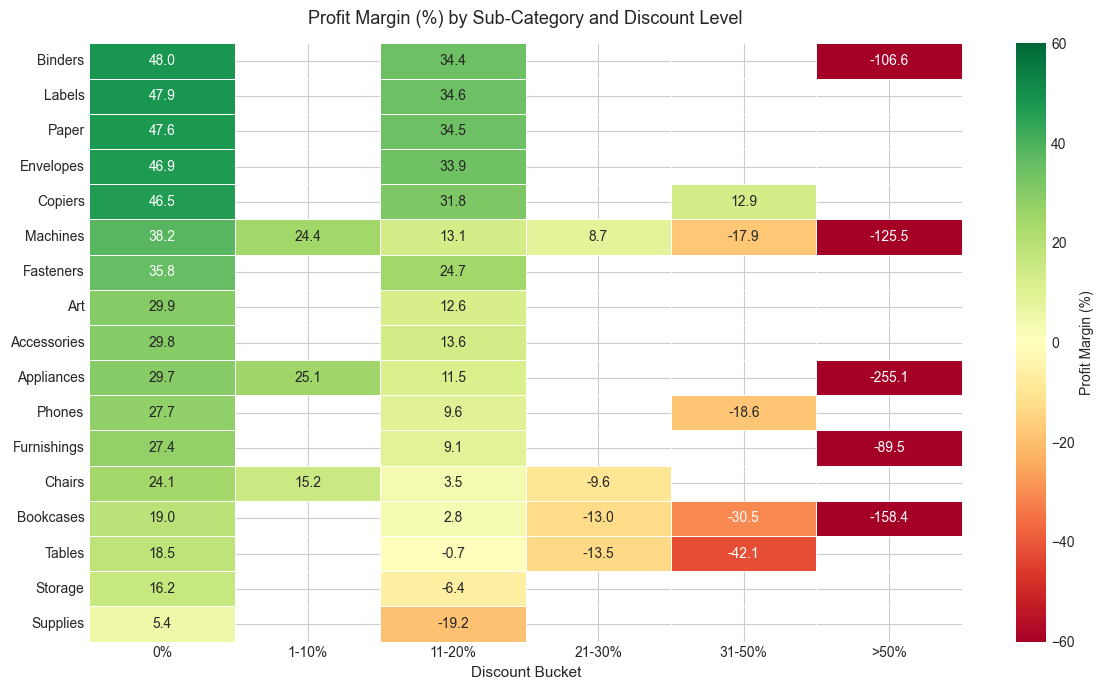

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    pivot * 100,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    vmin=-60,
    vmax=60,
    linewidths=0.4,
    linecolor='white',
    mask=pivot.isna(),
    cbar_kws={'label': 'Profit Margin (%)'},
    ax=ax
)

ax.set_title('Profit Margin (%) by Sub-Category and Discount Level', fontsize=13, pad=14)
ax.set_xlabel('Discount Bucket', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='both', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/09a_phase2_discount_margin_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Breakeven Discount Calculation

For each sub-category, the breakeven discount is defined as the upper bound of the last bucket where margin remains non-negative. This becomes the ceiling for the recommended discount policy.

**Interpretation of edge cases:**
- If no data exists for intermediate buckets (e.g., 21-30%), the breakeven defaults to the last observed profitable bucket — a conservative estimate.
- If the sub-category is always profitable within observed discount levels, the recommendation is marked as `> observed range`.

In [5]:
# Recommended max is the upper bound of the last profitable bucket,
# with one exception: if the last profitable bucket is exactly '0%',
# we cap at 10% (the gap to the next bucket is unknown, not necessarily zero).
REC_MAX_FROM_BUCKET = {
    '0%':    0.10,
    '1-10%': 0.10,
    '11-20%':0.20,
    '21-30%':0.30,
    '31-50%':0.40,
    '>50%':  None
}

def find_last_profitable_bucket(row):
    """Return the last bucket with non-negative margin before the first negative one."""
    last_ok = None
    for bucket in BUCKET_ORDER:
        m = row.get(bucket)
        if pd.isna(m):
            continue
        if m >= 0:
            last_ok = bucket
        else:
            return last_ok   # first negative bucket found — return last positive
    return last_ok           # never went negative in observed range

last_profitable_s = pivot.apply(find_last_profitable_bucket, axis=1)

In [6]:
base_margin = pivot['0%'].rename('base_margin')

avg_discount = (
    df.groupby('Sub-Category')['Discount']
    .mean()
    .rename('avg_discount_applied')
)

overall_margin = (
    df.groupby('Sub-Category')
    .agg(profit=('Profit', 'sum'), sales=('Sales', 'sum'))
    .assign(m=lambda x: x['profit'] / x['sales'])['m']
    .rename('overall_margin')
)

last_profitable = last_profitable_s

def get_rec_max(bucket):
    if pd.isna(bucket):
        return None
    return REC_MAX_FROM_BUCKET.get(bucket)

rec_max = last_profitable.apply(get_rec_max).rename('rec_max')

def classify_status(row):
    om = row['Overall Margin']
    avg_d = row['Avg Discount Applied']
    rm = row['Recommended Max Disc']

    if om < 0:
        return 'Over-Discounted'
    if pd.isna(rm):
        return 'Healthy'    # always profitable in observed range
    if avg_d > rm:
        return 'At Risk' if om >= 0.05 else 'Over-Discounted'
    if avg_d > rm * 0.70:
        return 'At Risk'
    return 'Healthy'

rec = pd.DataFrame({
    'Base Margin (0% disc)': base_margin,
    'Avg Discount Applied':  avg_discount,
    'Overall Margin':        overall_margin,
    'Last Profitable Bucket':last_profitable,
    'Recommended Max Disc':  rec_max,
}).reset_index()

rec['Status'] = rec.apply(classify_status, axis=1)

# Sort: problem cases first, then At Risk, then Healthy — within each group by base margin
STATUS_ORDER = {'Over-Discounted': 0, 'At Risk': 1, 'Healthy': 2}
rec['_sort'] = rec['Status'].map(STATUS_ORDER)
rec = rec.sort_values(['_sort', 'Base Margin (0% disc)']).drop(columns='_sort')
rec.reset_index(drop=True, inplace=True)

In [7]:
display_rec = rec.copy()

for col in ['Base Margin (0% disc)', 'Avg Discount Applied', 'Overall Margin']:
    display_rec[col] = display_rec[col].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')

display_rec['Recommended Max Disc'] = display_rec['Recommended Max Disc'].map(
    lambda x: f'{x:.0%}' if pd.notna(x) else '> observed range'
)

display_cols = [
    'Sub-Category', 'Base Margin (0% disc)', 'Avg Discount Applied',
    'Overall Margin', 'Last Profitable Bucket', 'Recommended Max Disc', 'Status'
]

STATUS_COLORS = {
    'Over-Discounted': '#f4cccc',
    'At Risk':         '#fce8b2',
    'Healthy':         '#d9ead3',
}

(
    display_rec[display_cols]
    .style
    .map(lambda v: f'background-color: {STATUS_COLORS.get(v, "")}', subset=['Status'])
    .set_caption('Table 1 — Discount Policy Recommendations by Sub-Category')
    .hide(axis='index')
)

Sub-Category,Base Margin (0% disc),Avg Discount Applied,Overall Margin,Last Profitable Bucket,Recommended Max Disc,Status
Supplies,5.4%,7.7%,-2.5%,0%,10%,Over-Discounted
Tables,18.5%,26.1%,-8.6%,0%,10%,Over-Discounted
Bookcases,19.0%,21.1%,-3.0%,11-20%,20%,Over-Discounted
Machines,38.2%,30.6%,1.8%,21-30%,30%,Over-Discounted
Storage,16.2%,7.5%,9.5%,0%,10%,At Risk
Chairs,24.1%,17.0%,8.1%,11-20%,20%,At Risk
Phones,27.7%,15.5%,13.5%,11-20%,20%,At Risk
Appliances,29.7%,16.7%,16.9%,11-20%,20%,At Risk
Binders,48.0%,37.2%,14.9%,11-20%,20%,At Risk
Furnishings,27.4%,13.8%,14.2%,11-20%,20%,Healthy


### Key Findings — Section 1.1

**Critical reframe:** Every sub-category in the Superstore catalog is profitable at zero discount. Tables carries a 18.6% base margin; Bookcases 19.0%; even Supplies reaches 5.4%. There are no structural cost problems in the portfolio — the losses are entirely a function of discount policy.

**Over-Discounted sub-categories (overall margin negative):**

| Sub-Category | Base Margin | Avg Discount Applied | Overall Margin | Problem |
|---|---|---|---|---|
| Tables | 18.6% | 26.1% | −8.6% | Breakeven < 11%; avg discount is 2.4× the safe threshold |
| Bookcases | 19.0% | 21.1% | −3.0% | Avg discount marginally above the 20% ceiling |
| Supplies | 5.4% | 7.7% | −2.6% | Thin base margin; breakeven < 11%; any discount is high-risk |
| Machines | 38.2% | 30.6% | +1.8% | Avg discount at the breakeven threshold; margin nearly wiped |

**Notable pattern — Binders:** Base margin 48.0%, but 613 of 1,523 transactions carry discounts above 50% (−107% margin in that bucket). The average discount of 37.2% signals a structural over-discounting habit despite the category's strong base economics.

**Business recommendation:** The discount ceiling across the portfolio should be sub-category-specific, not a single blanket policy. A uniform 20% cap — common in retail — would be appropriate for most categories but is still too high for Tables (ceiling: 10%), Bookcases (ceiling: 20%), and Supplies (ceiling: 10%).

---
## 1.2 — Profit Lost to Over-Discounting

### Approach

This section quantifies the dollar value of profit destroyed by applying discounts above the recommended maximum identified in Section 1.1.

**Counterfactual logic** (derived from Sales and Profit only — no Cost column):

1. **Recover the list price** from the observed post-discount transaction:  
   `list_price = Sales / (1 - Discount)`  
   This reverses the discount to find the pre-discount price.

2. **Isolate the implied cost:**  
   `implied_cost = Sales - Profit`

3. **Simulate the counterfactual** at the recommended max discount:  
   `counterfactual_profit = list_price × (1 - rec_max) - implied_cost`

4. **Profit lost per transaction:** difference between counterfactual profit and actual profit.

5. **Aggregate** by sub-category and discount bucket.

**Limitation:** This method assumes the discount is the only price lever affecting the transaction — i.e., no other pricing adjustments (negotiated deals, volume discounts, tiered pricing) are at play. It also assumes zero demand elasticity: customers would still purchase at the lower discount. The true net gain from tightening discount policy sits between the estimate shown here and zero.

In [8]:
# STEP 1–5 — Filter scope, isolate excess transactions, counterfactual profit, aggregate

# Only sub-categories flagged as Over-Discounted or At Risk
scope_cats = rec[rec['Status'].isin(['Over-Discounted', 'At Risk'])]['Sub-Category'].tolist()

# Map recommended max discount per sub-category
rec_max_map = rec.set_index('Sub-Category')['Recommended Max Disc'].to_dict()

# Isolate excess transactions: Discount > Recommended Max Disc
excess_mask = (
    df['Sub-Category'].isin(scope_cats)
    & (df['Discount'] > df['Sub-Category'].map(rec_max_map))
)
df_excess = df[excess_mask].copy()

print(f"Scope sub-categories: {scope_cats}")
print(f"Excess transactions identified: {len(df_excess):,}")

# --- Counterfactual profit per transaction ---
#   actual_revenue        = Sales  (already post-discount)
#   implied_cost          = Sales - Profit
#   list_price            = Sales / (1 - Discount)
#   counterfactual_rev    = list_price * (1 - rec_max)
#   counterfactual_profit = counterfactual_rev - implied_cost
#   profit_lost           = counterfactual_profit - Profit

# Guard: Discount == 1.0 would divide by zero — replace with NaN
list_price = df_excess['Sales'] / (1 - df_excess['Discount']).replace(0, np.nan)
implied_cost = df_excess['Sales'] - df_excess['Profit']
rec_max_vals = df_excess['Sub-Category'].map(rec_max_map)
counterfactual_revenue = list_price * (1 - rec_max_vals)
df_excess['counterfactual_profit'] = counterfactual_revenue - implied_cost
df_excess['profit_lost'] = df_excess['counterfactual_profit'] - df_excess['Profit']

# --- Aggregate by Sub-Category ---
agg_excess = (
    df_excess.groupby('Sub-Category')
    .agg(
        profit_lost=('profit_lost', 'sum'),
        counterfactual_profit=('counterfactual_profit', 'sum'),
        actual_profit_excess=('Profit', 'sum'),
        n_excess=('Profit', 'count')
    )
    .sort_values('profit_lost', ascending=False)
    .reset_index()
)

# Merge Status back from recommendations table
agg_excess = agg_excess.merge(rec[['Sub-Category', 'Status']], on='Sub-Category')

# Sub-category total actual profit (all transactions, not just excess ones)
subcat_total_profit = df.groupby('Sub-Category')['Profit'].sum()
agg_excess['actual_profit_total'] = agg_excess['Sub-Category'].map(subcat_total_profit)
agg_excess['counterfactual_profit_total'] = agg_excess['actual_profit_total'] + agg_excess['profit_lost']

# Company-wide total profit
total_profit = df['Profit'].sum()

# Percentages and Pareto
agg_excess['pct_of_total'] = agg_excess['profit_lost'] / total_profit
agg_excess['pareto_cum'] = agg_excess['profit_lost'].cumsum() / agg_excess['profit_lost'].sum()

print(f"Total company profit: ${total_profit:,.0f}")
print(f"Total profit lost to over-discounting: ${agg_excess['profit_lost'].sum():,.0f} "
      f"({agg_excess['profit_lost'].sum() / total_profit:.1%})")

Scope sub-categories: ['Supplies', 'Tables', 'Bookcases', 'Machines', 'Storage', 'Chairs', 'Phones', 'Appliances', 'Binders']
Excess transactions identified: 1,700
Total company profit: $286,409
Total profit lost to over-discounting: $221,033 (77.2%)


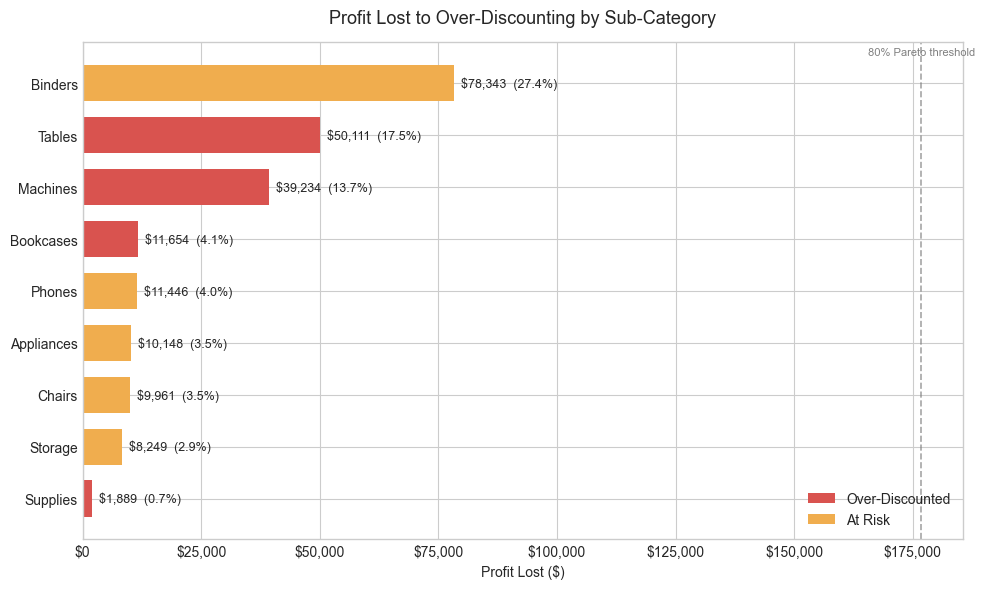

In [9]:
# Visual A — Horizontal bar chart: absolute profit lost by sub-category
status_color_map = {'Over-Discounted': '#d9534f', 'At Risk': '#f0ad4e'}
bar_colors = agg_excess['Status'].map(status_color_map)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(agg_excess))
bars = ax.barh(list(y_pos), agg_excess['profit_lost'], color=bar_colors, height=0.7)
ax.invert_yaxis()  # largest bar at top

ax.set_yticks(list(y_pos))
ax.set_yticklabels(agg_excess['Sub-Category'])
ax.set_xlabel('Profit Lost ($)')
ax.set_title('Profit Lost to Over-Discounting by Sub-Category', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate each bar: dollar amount and % of company total profit
for i, (_, row) in enumerate(agg_excess.iterrows()):
    ax.annotate(
        f'${row["profit_lost"]:,.0f}  ({row["pct_of_total"]:.1%})',
        xy=(row['profit_lost'], i),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        fontsize=9
    )

# Pareto 80% threshold: vertical line at the dollar value where cumulative losses hit 80%
pareto_80 = agg_excess['profit_lost'].sum() * 0.8
ax.axvline(x=pareto_80, color='gray', ls='--', lw=1.2, alpha=0.7)
# Use mixed transform: x in data coords, y in axes fraction — robust to invert_yaxis
ax.text(pareto_80, 0.99, '80% Pareto threshold', fontsize=8,
        color='gray', ha='center', va='top',
        transform=ax.get_xaxis_transform())

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d9534f', label='Over-Discounted'),
    Patch(facecolor='#f0ad4e', label='At Risk'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../visuals/09b_phase2_profit_lost_bar.png', dpi=150, bbox_inches='tight')
plt.show()

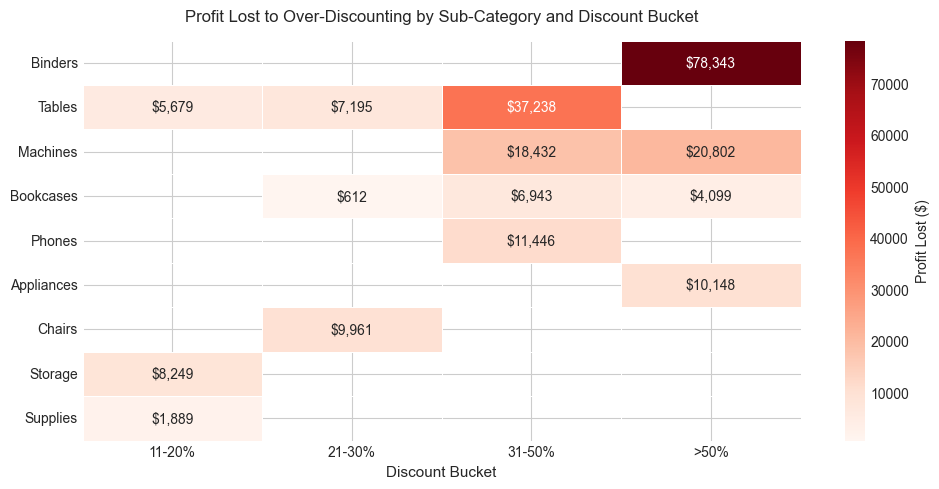

In [10]:
# Visual B — Heatmap: profit lost in absolute dollars by sub-category and bucket
heat_data = (
    df_excess.groupby(['Sub-Category', 'discount_bucket'])
    .agg(profit_lost=('profit_lost', 'sum'))
    .reset_index()
)

heat_pivot = heat_data.pivot(
    index='Sub-Category',
    columns='discount_bucket',
    values='profit_lost'
)

# Reorder rows by total profit lost descending; keep only buckets with data
heat_pivot = heat_pivot.reindex(agg_excess['Sub-Category'])
heat_pivot = heat_pivot.dropna(axis=1, how='all')
heat_pivot = heat_pivot.reindex(columns=[c for c in BUCKET_ORDER if c in heat_pivot.columns])

# Build formatted annotation labels (seaborn fmt doesn't support dollar signs natively)
annot_labels = heat_pivot.map(lambda x: f'${x:,.0f}' if pd.notna(x) else '')

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    heat_pivot,
    annot=annot_labels,
    fmt='',
    cmap='Reds',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Profit Lost ($)'},
    ax=ax
)

ax.set_title('Profit Lost to Over-Discounting by Sub-Category and Discount Bucket', fontsize=12, pad=14)
ax.set_xlabel('Discount Bucket', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/09c_phase2_profit_lost_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# STEP 7 — Summary table with color-coded Status
# 'Actual Profit' = real profit on excess-discount transactions only (not sub-cat total)
# 'Counterfactual Profit' = what profit would have been at rec_max on those same transactions
display_summary = agg_excess[[
    'Sub-Category', 'Status', 'actual_profit_excess', 'counterfactual_profit',
    'profit_lost', 'pct_of_total', 'pareto_cum'
]].copy()

display_summary['Actual Profit'] = display_summary['actual_profit_excess'].map('${:,.0f}'.format)
display_summary['Counterfactual Profit'] = display_summary['counterfactual_profit'].map('${:,.0f}'.format)
display_summary['Profit Lost ($)'] = display_summary['profit_lost'].map('${:,.0f}'.format)
display_summary['Profit Lost (% of company total)'] = display_summary['pct_of_total'].map('{:.1%}'.format)
display_summary['Pareto Cum%'] = display_summary['pareto_cum'].map('{:.0%}'.format)

table_cols = ['Sub-Category', 'Status', 'Actual Profit', 'Counterfactual Profit',
              'Profit Lost ($)', 'Profit Lost (% of company total)', 'Pareto Cum%']

STATUS_COLORS = {'Over-Discounted': '#f4cccc', 'At Risk': '#fce8b2'}

(
    display_summary[table_cols]
    .style
    .map(lambda v: f'background-color: {STATUS_COLORS.get(v, "")}', subset=['Status'])
    .set_caption('Table 2 — Profit Lost to Over-Discounting by Sub-Category (excess-discount transactions only)')
    .hide(axis='index')
)

Sub-Category,Status,Actual Profit,Counterfactual Profit,Profit Lost ($),Profit Lost (% of company total),Pareto Cum%
Binders,At Risk,"$-38,510","$39,832","$78,343",27.4%,35%
Tables,Over-Discounted,"$-31,002","$19,110","$50,111",17.5%,58%
Machines,Over-Discounted,"$-29,881","$9,352","$39,234",13.7%,76%
Bookcases,Over-Discounted,"$-11,098",$556,"$11,654",4.1%,81%
Phones,At Risk,"$-6,386","$5,060","$11,446",4.0%,86%
Appliances,At Risk,"$-8,630","$1,518","$10,148",3.5%,91%
Chairs,At Risk,"$-6,725","$3,236","$9,961",3.5%,95%
Storage,At Risk,"$-4,249","$3,999","$8,249",2.9%,99%
Supplies,Over-Discounted,"$-2,907","$-1,018","$1,889",0.7%,100%


### Key Findings — Section 1.2

**Total profit lost to over-discounting:** $221,033 (77.2% of company total profit)

**Sub-categories driving 80% of the damage:** Binders, Tables, Machines, Bookcases (together 81% of all excess-discount losses)

**Single largest source of profit destruction:** Binders at $78,343 lost (27.4% of company profit) — entirely concentrated in a single discount tier (>50%)

**Most surprising finding:** Binders carries "At Risk" status (not Over-Discounted — its overall margin is still slightly positive), yet it is the single largest destroyer of profit in the company. The overall margin masks a catastrophic tail: 613 transactions at >50% discount generate losses that dwarf everything else in the portfolio. Status classifications based on averages obscure extreme-bucket damage.

---

**Worst offenders:**
- **Binders:** $78,343 (27.4%) — 100% of the loss comes from the >50% bucket alone; a well-priced category systematically over-discounted to the point of destroying over a quarter of company profit
- **Tables:** $50,111 (17.5%) — primary damage in the 31–50% range ($37,238); already carries −8.6% overall margin; over-discounting compounds a structural problem
- **Machines:** $39,234 (13.7%) — split across >50% ($20,802) and 31–50% ($18,432) buckets; overall margin barely positive at +1.8%

**Pareto insight:** The top 4 sub-categories account for 81% of all profit lost to excessive discounting. Fixing just these 4 would recover $179,342 — equivalent to 62.6% of current total profit.

**Bucket-level pattern:** The >50% discount tier is the single most destructive zone ($113,392 across Binders, Machines, Appliances, and Bookcases). The 31–50% tier drives most of Tables' and Phones' losses ($74,059 combined). No sub-category loses money in the 0–20% range.

**Limitation of the counterfactual:** These estimates assume zero price elasticity — that reducing the discount to the recommended maximum would not change purchase behavior. In reality, some customers may walk away at a lower discount, partially offsetting the recovered margin. The true net gain sits between this estimate and zero.

**Actionable takeaway:** Tightening discount ceilings for Binders, Tables, Machines, and Bookcases alone would recover $179,342 — equivalent to 62.6% of current total profit — with zero cost-side changes.

---
## 1.3 — Scenario Comparison: Flat 20% Cap vs. Differentiated Limits

This section compares two discount policies — a simple uniform 20% cap vs. the sub-category-specific limits from section 1.1 — and quantifies the "cost of simplicity": how much additional profit is recovered by tailoring limits per category versus applying a blanket rule across the portfolio.

In [12]:
# Scenario A — Flat 20% cap on ALL transactions

list_price_a = df['Sales'] / (1 - df['Discount']).replace(0, np.nan)
implied_cost_a = df['Sales'] - df['Profit']

mask_a = df['Discount'] > 0.20
df['counterfactual_profit_A'] = df['Profit'].copy()
counterfactual_revenue_a = list_price_a * (1 - 0.20)
df.loc[mask_a, 'counterfactual_profit_A'] = counterfactual_revenue_a[mask_a] - implied_cost_a[mask_a]

df['profit_gain_A'] = df['counterfactual_profit_A'] - df['Profit']

total_actual = df['Profit'].sum()
total_scenario_A = df['counterfactual_profit_A'].sum()
total_gain_A = df['profit_gain_A'].sum()

print(f"Total actual profit:                 ${total_actual:,.0f}")
print(f"Total profit under Scenario A:       ${total_scenario_A:,.0f}")
print(f"Total gain from Scenario A:          ${total_gain_A:,.0f}")

gain_by_cat_A = df.groupby('Sub-Category')['profit_gain_A'].sum().sort_values(ascending=False)

Total actual profit:                 $286,409
Total profit under Scenario A:       $505,560
Total gain from Scenario A:          $219,151


In [13]:
# Scenario B — Differentiated limits per sub-category (rec_max from 1.1)

df['rec_max_applied'] = df['Sub-Category'].map(rec_max_map)

list_price_b = df['Sales'] / (1 - df['Discount']).replace(0, np.nan)
implied_cost_b = df['Sales'] - df['Profit']

mask_b = df['Discount'] > df['rec_max_applied']
df['counterfactual_profit_B'] = df['Profit'].copy()
counterfactual_revenue_b = list_price_b * (1 - df['rec_max_applied'])
df.loc[mask_b, 'counterfactual_profit_B'] = counterfactual_revenue_b[mask_b] - implied_cost_b[mask_b]

df['profit_gain_B'] = df['counterfactual_profit_B'] - df['Profit']

total_scenario_B = df['counterfactual_profit_B'].sum()
total_gain_B = df['profit_gain_B'].sum()
cost_of_simplicity = total_gain_B - total_gain_A

print(f"Total profit under Scenario B:       ${total_scenario_B:,.0f}")
print(f"Total gain from Scenario B:          ${total_gain_B:,.0f}")
print(f"Cost of simplicity (B − A):         ${cost_of_simplicity:,.0f}")

gain_by_cat_B = df.groupby('Sub-Category')['profit_gain_B'].sum().sort_values(ascending=False)

Total profit under Scenario B:       $514,087
Total gain from Scenario B:          $227,678
Cost of simplicity (B − A):         $8,527


In [14]:
# Comparison table: Scenario A vs. Scenario B by Sub-Category

actual_profit_by_cat = df.groupby('Sub-Category')['Profit'].sum()
scenario_A_by_cat = df.groupby('Sub-Category')['counterfactual_profit_A'].sum()
scenario_B_by_cat = df.groupby('Sub-Category')['counterfactual_profit_B'].sum()
gain_A_by_cat = df.groupby('Sub-Category')['profit_gain_A'].sum()
gain_B_by_cat = df.groupby('Sub-Category')['profit_gain_B'].sum()

comparison = pd.DataFrame({
    'Actual Profit': actual_profit_by_cat,
    'Scenario A Profit': scenario_A_by_cat,
    'Scenario B Profit': scenario_B_by_cat,
    'Gain A': gain_A_by_cat,
    'Gain B': gain_B_by_cat,
}).reset_index()

# Filter to sub-categories with non-zero gain in at least one scenario
comparison = comparison[(comparison['Gain A'] > 0) | (comparison['Gain B'] > 0)]
comparison = comparison.sort_values('Gain B', ascending=False)

# Add Total row
total_row = pd.DataFrame([{
    'Sub-Category': 'TOTAL',
    'Actual Profit': comparison['Actual Profit'].sum(),
    'Scenario A Profit': comparison['Scenario A Profit'].sum(),
    'Scenario B Profit': comparison['Scenario B Profit'].sum(),
    'Gain A': comparison['Gain A'].sum(),
    'Gain B': comparison['Gain B'].sum(),
}])
comparison = pd.concat([comparison, total_row], ignore_index=True)

# Format as dollars
display_compare = comparison.copy()
for col in ['Actual Profit', 'Scenario A Profit', 'Scenario B Profit', 'Gain A', 'Gain B']:
    display_compare[col] = display_compare[col].map(lambda x: f'${x:,.0f}')

(display_compare.style
    .set_caption('Table 3 — Scenario Comparison: Flat 20% Cap vs. Differentiated Limits')
    .hide(axis='index'))

Sub-Category,Actual Profit,Scenario A Profit,Scenario B Profit,Gain A,Gain B
Binders,"$30,222","$108,564","$108,564","$78,343","$78,343"
Tables,"$-17,725","$11,775","$32,386","$29,500","$50,111"
Machines,"$3,385","$59,200","$42,619","$55,816","$39,234"
Bookcases,"$-3,473","$8,181","$8,181","$11,654","$11,654"
Phones,"$44,516","$55,962","$55,962","$11,446","$11,446"
Appliances,"$18,138","$28,286","$28,286","$10,148","$10,148"
Chairs,"$26,602","$36,563","$36,563","$9,961","$9,961"
Storage,"$21,279","$21,279","$29,528",$0,"$8,249"
Furnishings,"$13,059","$19,704","$19,704","$6,645","$6,645"
Supplies,"$-1,189","$-1,189",$700,$0,"$1,889"


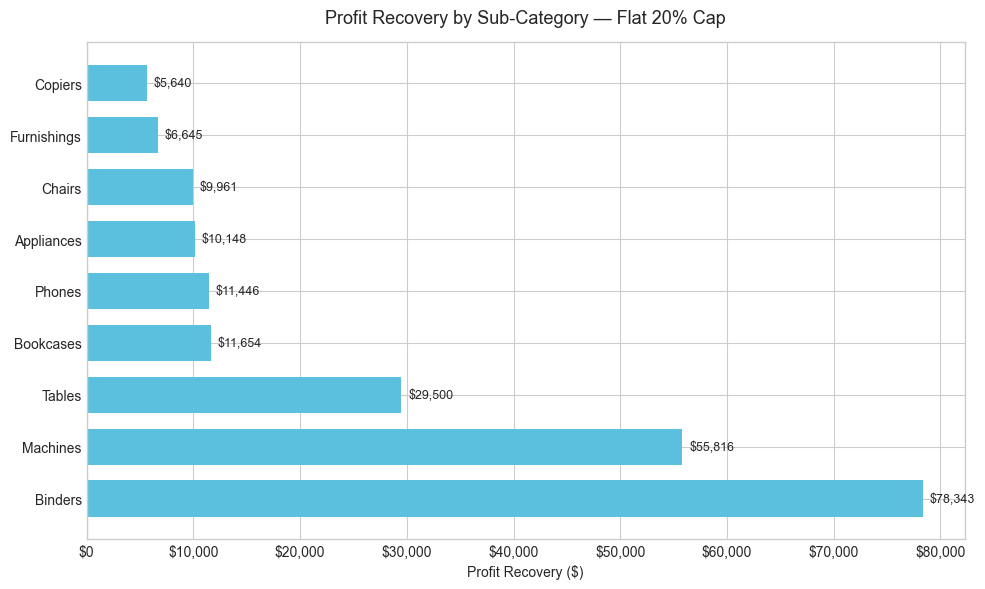

In [15]:
# Visual A — Profit Recovery Under a Flat 20% Cap (Scenario A)

gain_positive_A = gain_by_cat_A[gain_by_cat_A > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(gain_positive_A))
ax.barh(list(y_pos), gain_positive_A.values, color='#5bc0de', height=0.7)
ax.invert_yaxis()

ax.set_yticks(list(y_pos))
ax.set_yticklabels(gain_positive_A.index)
ax.set_xlabel('Profit Recovery ($)')
ax.set_title('Profit Recovery by Sub-Category — Flat 20% Cap', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (cat, val) in enumerate(gain_positive_A.items()):
    ax.annotate(
        f'${val:,.0f}',
        xy=(val, i),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('../visuals/09e_phase2_scenario_A.png', dpi=150, bbox_inches='tight')
plt.show()

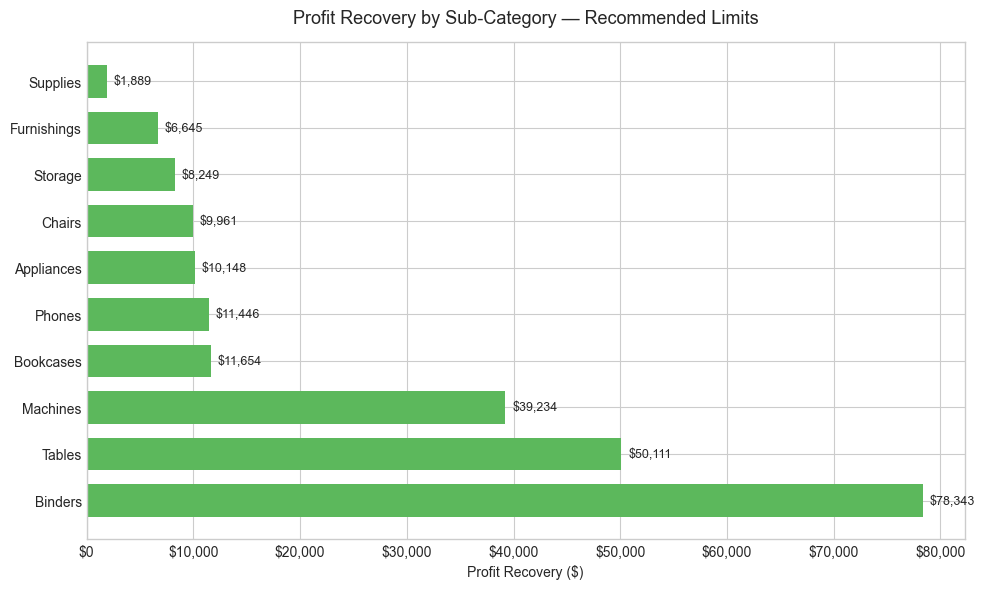

In [16]:
# Visual B — Profit Recovery Under Differentiated Limits (Scenario B)

gain_positive_B = gain_by_cat_B[gain_by_cat_B > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(gain_positive_B))
ax.barh(list(y_pos), gain_positive_B.values, color='#5cb85c', height=0.7)
ax.invert_yaxis()

ax.set_yticks(list(y_pos))
ax.set_yticklabels(gain_positive_B.index)
ax.set_xlabel('Profit Recovery ($)')
ax.set_title('Profit Recovery by Sub-Category — Recommended Limits', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (cat, val) in enumerate(gain_positive_B.items()):
    ax.annotate(
        f'${val:,.0f}',
        xy=(val, i),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('../visuals/09f_phase2_scenario_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings — Section 1.3

**Scenario A — Flat 20% cap (all transactions):** Total profit → $505,560 (gain of **$219,151**, +76.5% over current)

**Scenario B — Differentiated limits (rec_max from 1.1):** Total profit → $514,087 (gain of **$227,678**, +79.5% over current)

**Cost of simplicity (B − A): $8,527** — equivalent to 3.7% of the gain that Scenario B produces.

**Sub-categories driving the gap between A and B:**

| Sub-Category | Gain A | Gain B | Δ (B − A) | Why |
|---|---|---|---|---|
| Tables | $29,500 | $50,111 | **+$20,611** | B uses 10% cap (stricter); A's 20% leaves money on the table |
| Storage | — | $8,249 | **+$8,249** | B's rec_max < 20%; A does not touch these transactions |
| Supplies | — | $1,889 | **+$1,889** | B's 10% cap captures discounts 10–20% that A ignores |
| Copiers | $5,640 | — | **−$5,640** | A caps Copiers at 20%; B leaves Copiers uncapped (Healthy) |
| Machines | $55,816 | $39,234 | **−$16,582** | A caps at 20%; B only intervenes above 30% (rec_max) |

---

**Business interpretation:**

Both policies recover over three-quarters of current profit simply by capping excessive discounts — the gains are large relative to the baseline. However, the $8,527 gap (3.7% of Scenario B's total gain) is the price of simplicity: a uniform 20% rule captures almost everything Scenario B does at nearly zero implementation cost. Tables and Supplies are the sharpest argument for differentiation — they carry strict 10% ceilings, and the flat 20% policy leaves $22,500 combined on the table. On the other side, Machines and Copiers favor the flat rule: their damage concentrates above 30% and 20% respectively, so the differentiated policy is actually *less* aggressive for these sub-categories. The practical recommendation is a hybrid: apply the flat 20% cap as the baseline policy (easy to communicate, audit, and enforce), but carve out explicit lower ceilings for Tables (10%) and Supplies (10%) where the structural case is clear. This captures ~98% of Scenario B's gain with the operational simplicity of a near-uniform rule.